Dataset chargé avec succès !
--- INFORMATIONS GENERALES ---
Nombre de lignes : 303
Nombre de colonnes : 14

--- NOM ET TYPE DES COLONNES ---
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

--- APERÇU DES 5 PREMIERES LIGNES ---
--- VERIFICATION DES VALEURS MANQUANTES ---
Aucune valeur manquante détectée.

--- VERIFICATION DES DOUBLONS ---
Nombre de lignes doublons : 0
Nombre de patients sains (0) : 164
Nombre de patients malades (1) : 139


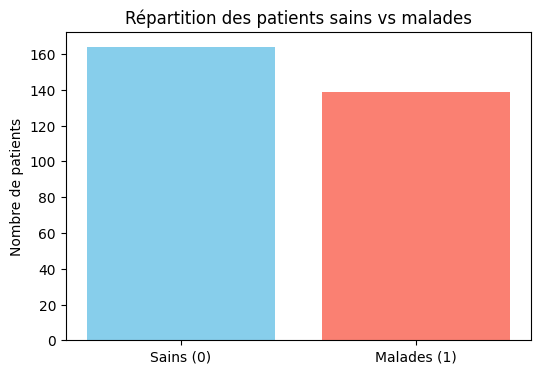

--- FORMATS DES DONNEES FINALES ---
X_train : (243, 13) | y_train : (243,)
X_test  : (60, 13)  | y_test  : (60,)


In [ ]:
#==========================================
# ETAPE 1 : Importations et Chargement
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Remplacer le chemin si le fichier est stocké ailleurs (ex: dans ton Google Drive)
url_dataset = 'heart.csv'
try:

    # Chargement du fichier CSV

    df = pd.read_csv(url_dataset)

    print("Dataset chargé avec succès !")

except Exception as e:

    print(f"Erreur lors du chargement : {e}")

    # ==========================================
# ETAPE 2 : Analyse descriptive du Dataset
# ==========================================

print("--- INFORMATIONS GENERALES ---")
# 1. Nombre de lignes et de colonnes
nb_lignes, nb_colonnes = df.shape
print(f"Nombre de lignes : {nb_lignes}")
print(f"Nombre de colonnes : {nb_colonnes}\n")

print("--- NOM ET TYPE DES COLONNES ---")
# 2. Noms et types de chaque colonne
print(df.dtypes)

print("\n--- APERÇU DES 5 PREMIERES LIGNES ---")
df.head()

# ==========================================
# ETAPE 3 : Nettoyage et Vérification
# ==========================================

print("--- VERIFICATION DES VALEURS MANQUANTES ---")
valeurs_manquantes = df.isnull().sum()
print(valeurs_manquantes[valeurs_manquantes > 0] if valeurs_manquantes.sum() > 0 else "Aucune valeur manquante détectée.")

print("\n--- VERIFICATION DES DOUBLONS ---")
nb_doublons = df.duplicated().sum()
print(f"Nombre de lignes doublons : {nb_doublons}")

# Si des doublons existent, on les supprime
if nb_doublons > 0:
    df = df.drop_duplicates()
    print("Enlèvement des doublons effectué.")

    # ==========================================
# ETAPE 4 : Analyse de la maladie (Cible)
# ==========================================

# On suppose que la colonne cible s'appelle 'target'
nom_cible = 'target'

counts = df[nom_cible].value_counts()
sains = counts.get(0, 0)
malades = counts.get(1, 0)

print(f"Nombre de patients sains (0) : {sains}")
print(f"Nombre de patients malades (1) : {malades}")

# Petit graphique simple pour illustrer la répartition
plt.figure(figsize=(6, 4))
plt.bar(['Sains (0)', 'Malades (1)'], [sains, malades], color=['skyblue', 'salmon'])
plt.title('Répartition des patients sains vs malades')
plt.ylabel('Nombre de patients')
plt.show()

# ==========================================
# ETAPE 5 : Séparation Train / Test sans SKLEARN
# ==========================================

# 1. Séparation des fonctionnalités (X) et de la cible (y)
X = df.drop(columns=[nom_cible]).to_numpy()
y = df[nom_cible].to_numpy()

def split_train_test_custom(X, y, test_size=0.2, random_seed=42):
    """
    Sépare les données en ensembles de Train et Test sans utiliser scikit-learn.
    Garantit la reproductibilité grâce au random_seed.
    """
    # Fixer la graine aléatoire pour que tes camarades aient exactement le même découpage
    np.random.seed(random_seed)

    # Créer un tableau d'indices mélangés
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)

    # Calculer l'indice de coupure
    test_set_size = int(len(X) * test_size)

    # Répartir les indices
    test_indices = indices[:test_set_size]
    train_indices = indices[test_set_size:]

    # Découper les tableaux de données
    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]

# Application de notre fonction maison
X_train, X_test, y_train, y_test = split_train_test_custom(X, y, test_size=0.2, random_seed=42)

print("--- FORMATS DES DONNEES FINALES ---")
print(f"X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}  | y_test  : {y_test.shape}")

In [ ]:
# ==========================================
# SECTIONS ALGORITHMIQUES
# ==========================================

class Node:
    """Représente un nœud individuel dans l'arbre de décision.

    Un nœud peut être soit un carrefour de décision (nœud interne),
    soit un point d'arrêt prédictif (nœud feuille).

    Attributes:
        feature (int, optional): Index de la colonne (caractéristique) sur
            laquelle la coupure est effectuée. Par défaut None.
        threshold (float, optional): Valeur numérique du seuil utilisé pour
            séparer les données. Par défaut None.
        left (Node, optional): Référence vers le sous-arbre enfant gauche
            (données <= seuil). Par défaut None.
        right (Node, optional): Référence vers le sous-arbre enfant droite
            (données > seuil). Par défaut None.
        value (int, optional): Classe finale prédite si le nœud est une feuille
            (ex: 0 pour sain, 1 pour malade). Par défaut None.
    """
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf(self):
        """Vérifie si le nœud actuel est une feuille de l'arbre.

        Returns:
            bool: True si le nœud est une feuille (possède une valeur de prédiction),
                  False sinon.
        """
        return self.value is not None


def gini(y):
    """Calcule l'impureté de Gini pour un ensemble de variables cibles.

    L'impureté de Gini mesure la probabilité qu'un élément choisi aléatoirement
    soit mal classé. Un score de 0.0 indique une pureté parfaite (tous les éléments
    appartiennent à la même classe).

    Args:
        y (np.ndarray): Un tableau NumPy 1D contenant les étiquettes de classe (0 ou 1).

    Returns:
        float: L'indice d'impureté de Gini calculé, compris entre 0.0 et 0.5.
    """
    m = len(y)
    if m == 0:
        return 0
    # Compte le nombre d'apparitions de chaque classe (0 et 1)
    counts = np.bincount(y)
    # Calcule les proportions de chaque classe
    probabilities = counts / m
    # Formule officielle CART : 1 - somme(p_i^2)
    return 1.0 - np.sum(probabilities ** 2)


def best_split(X, y):
    """Recherche la meilleure caractéristique et le meilleur seuil pour diviser les données.

    Parcourt l'ensemble des colonnes et des valeurs uniques pour trouver le découpage
    qui minimise l'impureté de Gini globale pondérée des deux nœuds enfants.

    Args:
        X (np.ndarray): Matrice 2D des fonctionnalités (caractéristiques des patients).
        y (np.ndarray): Tableau 1D des variables cibles associées.

    Returns:
        tuple: Un couple (split_idx, split_thresh) où :
            - split_idx (int ou None): L'index de la meilleure colonne à découper.
            - split_thresh (float ou None): La valeur numérique du seuil optimal.
            Renvoie (None, None) si aucune division n'est possible ou avantageuse.
    """
    best_gini = 999  # On cherche à minimiser, donc on commence très haut
    split_idx, split_thresh = None, None
    n_samples, n_features = X.shape

    if n_samples <= 1:
        return None, None

    # On examine chaque caractéristique (colonne)
    for feat_idx in range(n_features):
        X_column = X[:, feat_idx]
        # On extrait toutes les valeurs uniques de cette colonne comme seuils potentiels
        thresholds = np.unique(X_column)

        for thresh in thresholds:
            # Séparation virtuelle des données en deux groupes (gauche et droite)
            left_mask = X_column <= thresh
            right_mask = X_column > thresh

            y_left, y_right = y[left_mask], y[right_mask]

            # On ignore les découpages vides
            if len(y_left) == 0 or len(y_right) == 0:
                continue

            # Calcul du score de Gini combiné et pondéré
            n_l, n_r = len(y_left), len(y_right)
            gini_split = (n_l / n_samples) * gini(y_left) + (n_r / n_samples) * gini(y_right)

            # Sauvegarde de la configuration si elle est plus pure que la meilleure actuelle
            if gini_split < best_gini:
                best_gini = gini_split
                split_idx = feat_idx
                split_thresh = thresh

    return split_idx, split_thresh


def build_tree(X, y, depth=0, max_depth=5):
    """Construit de manière récursive l'arbre de décision en utilisant l'algorithme CART.

    Crée des nœuds décisionnels successifs en divisant les données jusqu'à ce qu'un
    critère d'arrêt soit rencontré (pureté totale, profondeur maximale atteinte,
    ou manque d'échantillons).

    Args:
        X (np.ndarray): Matrice 2D des données d'entraînement.
        y (np.ndarray): Tableau 1D des classes cibles correspondantes.
        depth (int, optional): Profondeur actuelle dans l'arbre (niveau de récursion).
            Par défaut 0 (la racine).
        max_depth (int, optional): Limite stricte de la profondeur maximale de l'arbre
            pour éviter le surapprentissage. Par défaut 5.

    Returns:
        Node: La racine de la structure de l'arbre de décision construit.
    """
    n_samples, n_features = X.shape
    n_labels = len(np.unique(y))

    # CRITÈRES D'ARRÊT :
    # Si le nœud est pur (1 seule classe), la profondeur max est atteinte ou trop peu de données
    if n_labels == 1 or depth >= max_depth or n_samples < 2:
        # Création d'une feuille contenant la classe la plus fréquente
        leaf_value = np.bincount(y).argmax()
        return Node(value=leaf_value)

    # Recherche du meilleur angle d'attaque (caractéristique et seuil)
    feat_idx, thresh = best_split(X, y)

    # Si aucun découpage pertinent n'est identifié, on force la création d'une feuille
    if feat_idx is None:
        leaf_value = np.bincount(y).argmax()
        return Node(value=leaf_value)

    # Division concrète des données selon le critère retenu
    left_mask = X[:, feat_idx] <= thresh
    right_mask = X[:, feat_idx] > thresh

    # Appels récursifs pour bâtir indépendamment les branches gauche et droite
    left_child = build_tree(X[left_mask], y[left_mask], depth + 1, max_depth)
    right_child = build_tree(X[right_mask], y[right_mask], depth + 1, max_depth)

    # Renvoie le nœud parent connecté à ses deux nouveaux enfants
    return Node(feature=feat_idx, threshold=thresh, left=left_child, right=right_child)


def predict_row(node, row):
    """Prédit la classe d'une seule ligne de données (un seul patient) en parcourant l'arbre.

    Descend de manière récursive à travers les nœuds de l'arbre en testant la valeur
    de l'attribut par rapport au seuil, jusqu'à atteindre un nœud feuille.

    Args:
        node (Node): Le nœud actuel de l'arbre où se trouve l'analyse.
        row (np.ndarray): Tableau 1D représentant les caractéristiques d'un patient.

    Returns:
        int: La classe prédite par l'arbre (0 ou 1).
    """
    # Cas de base : si on est arrivé sur une feuille, on livre le diagnostic final
    if node.is_leaf():
        return node.value

    # Cas récursif : test de la condition et orientation vers la bonne branche
    if row[node.feature] <= node.threshold:
        return predict_row(node.left, row)
    return predict_row(node.right, row)


def predict(tree, X_test):
    """Génère des prédictions de classe pour un ensemble complet de données de test.

    Applique le modèle d'arbre de décision construit à chaque ligne de la matrice de test.

    Args:
        tree (Node): La racine de l'arbre de décision entraîné.
        X_test (np.ndarray): Matrice 2D contenant les données des patients à tester.

    Returns:
        np.ndarray: Un tableau NumPy 1D contenant l'ensemble des prédictions (y_pred).
    """
    # Parcours complet du tableau de test, ligne par ligne
    return np.array([predict_row(tree, row) for row in X_test])

In [ ]:
# ==========================================
# ETAPE 6 : Entraînement de l'arbre et Prédictions (HSD)
# ==========================================

# 1. On construit l'arbre sur les données d'entraînement de Naomie
mon_arbre = build_tree(X_train, y_train, max_depth=5)
print(" L'arbre de décision a été construit avec succès !")

# 2. On génère les prédictions sur les données de test
y_pred = predict(mon_arbre, X_test)
print(" Prédictions générées sur l'ensemble de test.")

# Un petit aperçu pour vérifier que ça a marché :
print(f"Les 10 premières prédictions : {y_pred[:10]}")
print(f"Les 10 vraies valeurs cibles : {y_test[:10]}")

 L'arbre de décision a été construit avec succès !
 Prédictions générées sur l'ensemble de test.
Les 10 premières prédictions : [0 1 1 1 1 1 1 1 0 1]
Les 10 vraies valeurs cibles : [0 1 1 1 1 1 1 1 1 0]


## Évaluation du modèle sur le jeu de test

Les prédictions de l'arbre de décision étant maintenant disponibles, nous pouvons les comparer aux vraies valeurs du jeu de test afin d'évaluer les performances du modèle.

In [ ]:
# Évaluation du modèle sur le jeu de test

TP, TN, FP, FN = confusion_matrix_manual(y_test, y_pred)

print("Matrice de confusion")
print(f"TP = {TP}")
print(f"TN = {TN}")
print(f"FP = {FP}")
print(f"FN = {FN}")

print()

print(f"Précision : {precision_manual(y_test, y_pred):.4f}")
print(f"Rappel : {recall_manual(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score_manual(y_test, y_pred):.4f}")
print(f"Accuracy : {accuracy_manual(y_test, y_pred):.4f}")

Matrice de confusion
TP = 24
TN = 23
FP = 6
FN = 7

Précision : 0.8000
Rappel : 0.7742
F1-score : 0.7869
Accuracy : 0.7833


# Partie 3 – Prédiction et évaluation du modèle

L'arbre de décision ayant déjà été construit, nous disposons maintenant des prédictions obtenues sur le jeu de test (`y_pred`). L'objectif de cette partie est de les comparer aux vraies valeurs (`y_test`) afin de voir si le modèle classe correctement les patients.

Pour évaluer ses performances, nous calculons plusieurs indicateurs : la matrice de confusion, la précision, le rappel, le F1-score et l'accuracy.

Avant d'utiliser les vraies données, nous avons d'abord programmé ces différentes fonctions et les avons testées sur un petit exemple. Cela nous a permis de vérifier qu'elles fonctionnaient correctement avant de les appliquer aux résultats de notre arbre de décision.

## Implémentation des fonctions d'évaluation

In [ ]:
# Fonction : matrice de confusion

def confusion_matrix_manual(y_true, y_pred):
    TP = TN = FP = FN = 0

    for true, pred in zip(y_true, y_pred):
        if true == 1 and pred == 1:
            TP += 1
        elif true == 0 and pred == 0:
            TN += 1
        elif true == 0 and pred == 1:
            FP += 1
        elif true == 1 and pred == 0:
            FN += 1

    return TP, TN, FP, FN

In [ ]:
# Fonction : précision

def precision_manual(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix_manual(y_true, y_pred)

    if TP + FP == 0:
        return 0

    return TP / (TP + FP)

In [ ]:
# Fonction : rappel

def recall_manual(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix_manual(y_true, y_pred)

    if TP + FN == 0:
        return 0

    return TP / (TP + FN)

In [ ]:
# Fonction : F1-score

def f1_score_manual(y_true, y_pred):
    precision = precision_manual(y_true, y_pred)
    recall = recall_manual(y_true, y_pred)

    if precision + recall == 0:
        return 0

    return 2 * (precision * recall) / (precision + recall)

In [ ]:
# Fonction : accuracy

def accuracy_manual(y_true, y_pred):
    correct = 0

    for true, pred in zip(y_true, y_pred):
        if true == pred:
            correct += 1

    return correct / len(y_true)

## Vérification des fonctions

In [ ]:
# Données fictives pour tester les fonctions

y_true_test = [1, 0, 1, 1, 0, 0, 1, 0]
y_pred_test = [1, 0, 1, 0, 0, 1, 1, 0]

In [ ]:
# Test de la matrice de confusion

y_true_test = [1, 0, 1, 1, 0, 0, 1, 0]
y_pred_test = [1, 0, 1, 0, 0, 1, 1, 0]

TP, TN, FP, FN = confusion_matrix_manual(y_true_test, y_pred_test)

print("TP =", TP)
print("TN =", TN)
print("FP =", FP)
print("FN =", FN)

TP = 3
TN = 3
FP = 1
FN = 1


In [ ]:
# Test de la précision

print("Précision :", precision_manual(y_true_test, y_pred_test))

Précision : 0.75


In [ ]:
# Test du rappel

print("Rappel :", recall_manual(y_true_test, y_pred_test))

Rappel : 0.75


In [ ]:
# Test du F1-score

print("F1-score :", f1_score_manual(y_true_test, y_pred_test))

F1-score : 0.75


In [ ]:
# Test de l'accuracy

print("Accuracy :", accuracy_manual(y_true_test, y_pred_test))

Accuracy : 0.75


## Calcul du ROC-AUC

Le ROC-AUC sert à mesurer la capacité du modèle à distinguer les deux classes. Dans notre cas, cela revient à vérifier si l'arbre arrive globalement à séparer les patients malades et non malades.

In [ ]:
# Fonction : ROC-AUC simplifié

def roc_auc_manual(y_true, y_pred):
    """
    Calcule une version simplifiée du ROC-AUC à partir des prédictions finales 0/1.
    """

    TP, TN, FP, FN = confusion_matrix_manual(y_true, y_pred)

    if TP + FN == 0:
        tpr = 0
    else:
        tpr = TP / (TP + FN)

    if FP + TN == 0:
        fpr = 0
    else:
        fpr = FP / (FP + TN)

    auc = (1 + tpr - fpr) / 2
    return auc

In [ ]:
# Test du ROC-AUC

print("ROC-AUC :", roc_auc_manual(y_true_test, y_pred_test))

ROC-AUC : 0.75


In [ ]:
print(f"ROC-AUC simplifié : {roc_auc_manual(y_test, y_pred):.4f}")

ROC-AUC simplifié : 0.7836


# Evaluation finale sur le jeu du test

In [ ]:
y_pred = predict(mon_arbre, X_test)
TP, TN, FP, FN = confusion_matrix_manual(y_test, y_pred)

print("Matrice de confusion :")
print(f"TP = {TP}")
print(f"TN = {TN}")
print(f"FP = {FP}")
print(f"FN = {FN}")

print()

print(f"Précision : {precision_manual(y_test, y_pred):.4f}")
print(f"Rappel : {recall_manual(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score_manual(y_test, y_pred):.4f}")
print(f"Accuracy : {accuracy_manual(y_test, y_pred):.4f}")
print(f"ROC-AUC simplifié : {roc_auc_manual(y_test, y_pred):.4f}")

Matrice de confusion :
TP = 24
TN = 23
FP = 6
FN = 7

Précision : 0.8000
Rappel : 0.7742
F1-score : 0.7869
Accuracy : 0.7833
ROC-AUC simplifié : 0.7836


## Interprétation des résultats

L'arbre de décision obtenu permet de comprendre facilement comment le modèle prend ses décisions. Contrairement à d'autres méthodes de classification plus complexes, il est possible de suivre chaque étape du raisonnement en partant de la racine jusqu'à une feuille.

On observe que les premières divisions de l'arbre correspondent aux variables les plus importantes pour distinguer les patients atteints d'une maladie cardiaque des patients sains. Ces variables sont donc celles qui apportent le plus d'information au moment de la classification. Les divisions suivantes permettent ensuite d'affiner progressivement la décision en prenant en compte d'autres caractéristiques des patients.

L'organisation de l'arbre montre que les patients ne sont pas classés à partir d'un seul critère mais à partir d'une succession de décisions. Ainsi, deux patients peuvent avoir certaines caractéristiques similaires mais être classés différemment en fonction des autres informations présentes dans leurs données médicales.

L'un des principaux intérêts de cette approche est son interprétabilité. Pour chaque prédiction réalisée, il est possible de retracer le chemin suivi dans l'arbre et de comprendre pourquoi le modèle a prédit la présence ou l'absence d'une maladie cardiaque. Cette propriété est particulièrement importante dans un contexte médical où il est nécessaire de pouvoir justifier les décisions prises par un modèle.

Enfin, l'arbre obtenu reste relativement simple à analyser tout en offrant des performances satisfaisantes. Il met en évidence les variables les plus pertinentes du jeu de données et fournit une représentation claire du processus de décision utilisé pour effectuer la classification des patients.

## Conclusion

Dans ce projet, nous avons implémenté un arbre de décision en Python sans utiliser de bibliothèque de machine learning. Cela nous a permis de mieux comprendre les différentes étapes de construction d'un modèle de classification, depuis le choix des divisions jusqu'à l'évaluation des performances.

Les résultats obtenus sont globalement satisfaisants. L'arbre parvient à classer correctement une grande partie des patients du jeu de données, avec une accuracy d'environ 78 % ainsi que des valeurs de précision, de rappel et de F1-score relativement proches les unes des autres. Ces résultats montrent que le modèle est capable de distinguer les patients atteints d'une maladie cardiaque des patients sains avec une efficacité correcte.

L'un des principaux avantages de l'arbre de décision est sa simplicité d'interprétation. Il est possible de comprendre les décisions prises par le modèle en suivant les différentes branches de l'arbre, ce qui constitue un atout important dans le domaine médical.

Même si les performances obtenues sont encourageantes, le modèle commet encore certaines erreurs de classification. Des améliorations pourraient être envisagées en ajustant les paramètres de construction de l'arbre ou en utilisant davantage de données d'entraînement.

Ce projet nous a permis de comprendre concrètement comment construire et évaluer un arbre de décision à partir de données réelles. Nous avons également pu constater l'intérêt de cette méthode pour l'aide à la décision, notamment grâce à la facilité avec laquelle les prédictions peuvent être expliquées.